In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


# **Data Load From Kaggle**

Plant village dataset : Consists of many plant leaf images data with healthy leaves and unhealty (infected\virus affected leaf images).

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)



Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


# **Data Augementation Functions**
Transforming the data using different augmentation techniques.


In [5]:
import torchvision.transforms as transforms
size = 128
train_transform = transforms.Compose([
    transforms.Resize((size, size)),        # resize to model input size
    transforms.RandomHorizontalFlip(),    # horizontal flip augmentation
    transforms.RandomRotation(15),        # rotate \u00b115 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()                # convert PIL \u2192 tensor [0,1]
])

val_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
])


# **Data Preparation**

The plant village dataset consists of variety of plants, we are working with the Grapes leaf images only so here we separate the grape related images folders and load them for use.


In [6]:
from torch.utils.data import random_split
from torchvision import datasets # Added this import

# Define the root directory for the specific classes of interest
dataset_root = '/kaggle/input/plantvillage-dataset/plantvillage dataset/color/'

# Create a custom dataset that filters for the desired classes
class FilteredImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform=None, target_classes=None):
        super().__init__(root, transform=transform) # self.classes, self.class_to_idx, self.samples are populated here with ALL classes

        if target_classes is not None:
            # Keep a reference to the original class names and mapping before filtering self.classes
            # This is important because the 's[1]' in self.samples still refers to indices in this original list.
            original_full_classes = self.classes # e.g., ['Apple', 'Banana', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', ...]

            # Filter the samples first, keeping only those whose original class name is in target_classes
            # s[1] here is the original index into original_full_classes
            filtered_samples = []
            for s_path, s_original_idx in self.samples:
                if original_full_classes[s_original_idx] in target_classes:
                    filtered_samples.append((s_path, s_original_idx)) # Store (path, original_index) for now
            self.samples = filtered_samples

            # Now, create the new, filtered list of classes and their new 0-indexed mapping
            new_classes = [c for c in original_full_classes if c in target_classes]
            new_class_to_idx = {cls_name: i for i, cls_name in enumerate(new_classes)}

            # Update the instance's class attributes to reflect only the target classes
            self.classes = new_classes
            self.class_to_idx = new_class_to_idx

            # Finally, update the samples' target indices to the new 0-indexed mapping
            # For each (path, original_index) in self.samples, get the original class name
            # then map it to its new index using new_class_to_idx
            final_samples = []
            for s_path, s_original_idx in self.samples:
                original_class_name = original_full_classes[s_original_idx]
                new_class_idx = self.class_to_idx[original_class_name] # Use the newly set self.class_to_idx
                final_samples.append((s_path, new_class_idx))
            self.samples = final_samples

            # Update self.targets to reflect the new indices
            self.targets = [s[1] for s in self.samples]

# Specify the target classes
target_classes = [
    'Grape___healthy',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Grape___Esca_(Black_Measles)',
    'Grape___Black_rot'
]

# Load the full dataset, filtering for the target classes, without transformations yet
full_dataset = FilteredImageFolder(root=dataset_root, target_classes=target_classes)

# Split the dataset into training, validation, and test sets (70-15-15 split)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size # Remaining for test set

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Define a wrapper dataset to apply transformations to Subset objects
class DatasetWithTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        # Get the original image and label from the subset
        img, label = self.subset[index]
        # Apply transform if available
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)

# Create new datasets with transformations applied using the wrapper
train_data = DatasetWithTransform(train_dataset, transform=train_transform)
val_data = DatasetWithTransform(val_dataset, transform=val_transform)
test_data = DatasetWithTransform(test_dataset, transform=val_transform) # Apply val_transform to test data

print(f"Total dataset size: {len(full_dataset)}")
print(f"Training dataset size: {len(train_data)}")
print(f"Validation dataset size: {len(val_data)}")
print(f"Test dataset size: {len(test_data)}")
print(f"Classes in dataset: {full_dataset.classes}")

Total dataset size: 4062
Training dataset size: 2843
Validation dataset size: 609
Test dataset size: 610
Classes in dataset: ['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']


Sample Image of the Picutre

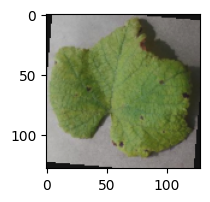

In [7]:
plt.figure(figsize = (2,2))
plt.imshow(train_data[800][0].permute(1,2,0))

# **Defining Parameters for Training and Loading**

In [20]:
#important HyperParameters
batch_size = 32
learning_rate=0.0001
minimum_learning_rate=1e-5
epochs = 20

In [21]:
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Number of batches in validation loader: {len(val_loader)}")
print(f"Number of batches in test loader: {len(test_loader)}")

Number of batches in training loader: 89
Number of batches in validation loader: 20
Number of batches in test loader: 20


# **Model Architecture**

Custom CNN with Batch Norm and Dropout and Wihtout batch norm and dropuout



In [55]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn as nn # Added this import

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # Feature extraction layers
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
         # Classification layers
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, len(target_classes)) # Updated to len(target_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

#1. Get the Model
model = CNNModel().to(device)
# 2. Define optimizer
optimizer = Adam(model.parameters(), lr=learning_rate)
# 3. Define LR scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=minimum_learning_rate)
# 4. Define loss function
criterion = nn.CrossEntropyLoss()

from torchsummary import summary
summary(model, input_size=(3,size,size));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]           9,248
       BatchNorm2d-5         [-1, 32, 128, 128]              64
              ReLU-6         [-1, 32, 128, 128]               0
         MaxPool2d-7           [-1, 32, 64, 64]               0
         Dropout2d-8           [-1, 32, 64, 64]               0
            Conv2d-9           [-1, 64, 64, 64]          18,496
             ReLU-10           [-1, 64, 64, 64]               0
           Conv2d-11           [-1, 64, 64, 64]          36,928
             ReLU-12           [-1, 64, 64, 64]               0
        MaxPool2d-13           [-1, 64, 32, 32]               0
AdaptiveAvgPool2d-14             [-1, 6

# **Training and Evaluating Definition**

In [56]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        # compute accuracy
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(loader)
    train_acc = correct / total

    return train_loss, train_acc

def validate_epoch(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    return val_loss, val_acc

# **Training the Model on Train and Validation Set**

In [57]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    print(f"----------------------------------------------------")
    print(f"Epoch {epoch+1}/{epochs}, LR: {optimizer.param_groups[0]['lr']:.6g}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

----------------------------------------------------
Epoch 1/20, LR: 0.0001
Train Loss: 0.8595 | Train Acc: 0.6592
Val Loss: 0.5591 | Val Acc: 0.8161
----------------------------------------------------
Epoch 2/20, LR: 9.9446e-05
Train Loss: 0.5459 | Train Acc: 0.8034
Val Loss: 0.3508 | Val Acc: 0.8949
----------------------------------------------------
Epoch 3/20, LR: 9.77975e-05
Train Loss: 0.4516 | Train Acc: 0.8466
Val Loss: 0.3707 | Val Acc: 0.8440
----------------------------------------------------
Epoch 4/20, LR: 9.50953e-05
Train Loss: 0.3884 | Train Acc: 0.8656
Val Loss: 0.2531 | Val Acc: 0.9179
----------------------------------------------------
Epoch 5/20, LR: 9.14058e-05
Train Loss: 0.3425 | Train Acc: 0.8860
Val Loss: 0.2945 | Val Acc: 0.9097
----------------------------------------------------
Epoch 6/20, LR: 8.68198e-05
Train Loss: 0.3155 | Train Acc: 0.8973
Val Loss: 0.2270 | Val Acc: 0.9245
----------------------------------------------------
Epoch 7/20, LR: 8.14503

# **Accuracy and Loss Curves on Training and Evaluation**

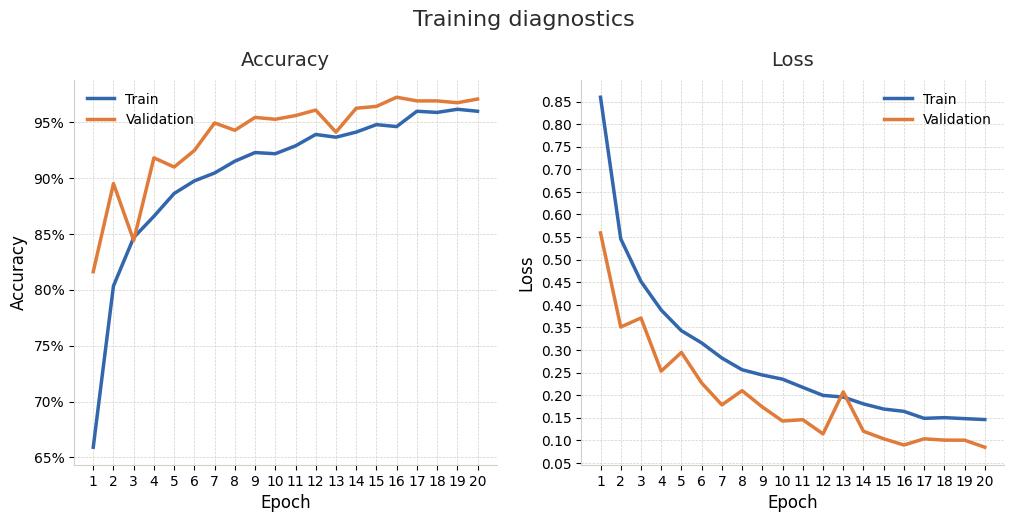

In [58]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import numpy as np

BLUE   = "#3266ad"
ORANGE = "#e07b39"
GRAY   = "#88877f"
BLACK  = "#000000"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#d3d1c7",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#d3d1c7",
    "grid.linewidth": 0.5,
    "grid.linestyle": "--",
    "xtick.color": BLACK,
    "ytick.color": BLACK,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

epochs_number = np.arange(1, epochs+1)
fig = plt.figure(figsize=(12, 5)) # Adjusted figure size for better aspect ratio
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.2)

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs_number, train_accuracies, color=BLUE,   lw=2.5,   label="Train") # Removed markers
ax1.plot(epochs_number, val_accuracies,   color=ORANGE, lw=2.5,   label="Validation") # Removed markers
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax1.set_xlabel("Epoch", color=BLACK, fontsize=12) # Increased font size
ax1.set_ylabel("Accuracy", color=BLACK, fontsize=12) # Increased font size
ax1.set_title("Accuracy", fontsize=14, fontweight="medium", color="#2c2c2a", pad=10) # Increased font size
ax1.legend(frameon=False, fontsize=10, labelcolor=BLACK)

# ── Loss ──────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs_number, train_losses, color=BLUE,   lw=2.5, label="Train") # Removed markers
ax2.plot(epochs_number, val_losses,   color=ORANGE, lw=2.5, label="Validation") # Removed markers
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax2.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax2.set_xlabel("Epoch", color=BLACK, fontsize=12) # Increased font size
ax2.set_ylabel("Loss",  color=BLACK, fontsize=12)  # Increased font size
ax2.set_title("Loss", fontsize=14, fontweight="medium", color="#2c2c2a", pad=10) # Increased font size
ax2.legend(frameon=False, fontsize=10, labelcolor=BLACK)

fig.suptitle("Training diagnostics", fontsize=16, fontweight="medium", color="#2c2c2a", y=1.02) # Increased font size
plt.savefig("training_curves.pdf", bbox_inches="tight", dpi=150)
plt.show()

# **Model Evaluation on Test Set and Evaluation Metrices**

In [59]:
from sklearn.metrics import classification_report

def evaluate_model_on_test_set(model, test_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\n--- Test Set Evaluation ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

# Evaluate the model on the test set
evaluate_model_on_test_set(model, test_loader, device, full_dataset.classes)


--- Test Set Evaluation ---
                                            precision    recall  f1-score   support

                         Grape___Black_rot       0.99      0.98      0.99       168
              Grape___Esca_(Black_Measles)       0.99      0.99      0.99       204
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)       0.99      0.99      0.99       163
                           Grape___healthy       1.00      1.00      1.00        75

                                  accuracy                           0.99       610
                                 macro avg       0.99      0.99      0.99       610
                              weighted avg       0.99      0.99      0.99       610



# **Confusion Matrix**


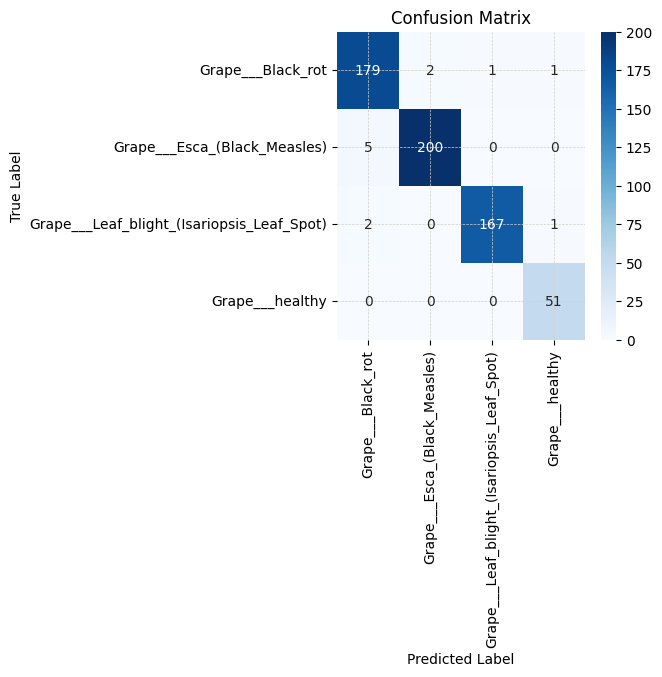

In [60]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# **Sample Prediction of a Picture**

showing the prediction result of the model of a sample picture

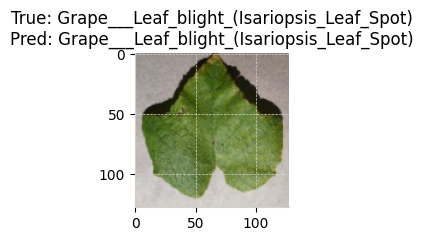

In [61]:
model.eval()
with torch.no_grad():
  ix = torch.randint(0,len(val_data),())
  img, true_label_idx = val_data[ix] # Get both image and true label
  img = img.unsqueeze(0).to(device)
  np_output = model(img).cpu().detach().numpy()
  pred = np.exp(np_output)/np.sum(np.exp(np_output))
  predicted_label_idx = pred[0].argmax()

  plt.figure(figsize=(2,2))
  plt.imshow(img.squeeze(0).permute(1,2,0).cpu().detach().numpy())
  plt.title(f"True: {full_dataset.classes[true_label_idx]}\nPred: {full_dataset.classes[predicted_label_idx]}")
  plt.show()

# **Missclassified Images**

showing the results of the missflasiffied images and true labels

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

class_names = full_dataset.classes  # from ImageFolder

model.eval()
misclassified = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device);
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # Save all predictions and labels for confusion matrix
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Store misclassified images
        for img, true, pred in zip(images, labels, preds):
            if true != pred:
                misclassified.append((img.cpu(), true.cpu(), pred.cpu()))

Total misclassified samples: 18


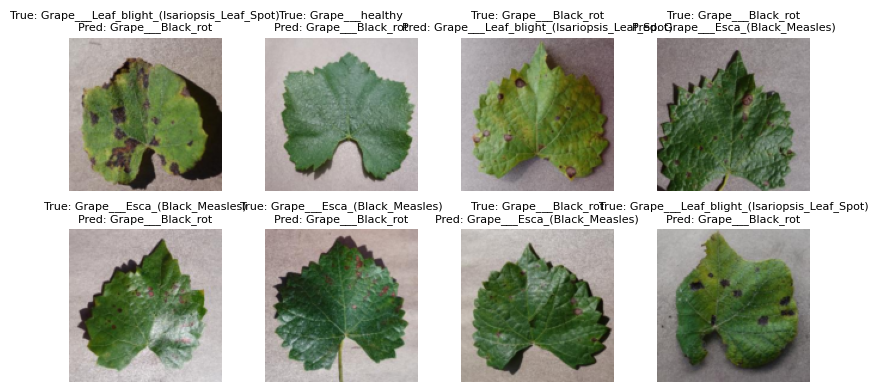

In [63]:
print(f"Total misclassified samples: {len(misclassified)}")
num_rows = 2
num_cols = 4
num_to_show = num_rows * num_cols
num_to_show = min(num_to_show, len(misclassified))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols*2, num_rows*2))
axes = axes.flatten()  # flatten for easy iteration

for idx in range(num_to_show):
    img, true, pred = misclassified[idx]
    img = img.permute(1, 2, 0)  # CxHxW -> HxWxC
    axes[idx].imshow(img)
    axes[idx].set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}", fontsize=8) # Lowered font size
    axes[idx].axis('off')

# Turn off any unused subplots
for idx in range(num_to_show, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [64]:
import torch

# Define a path to save the model weights
model_save_path = 'grape_disease_classifier.pth'

# Save the model's state dictionary
torch.save(model.state_dict(), model_save_path)

print(f"Model weights saved to {model_save_path}")

Model weights saved to grape_disease_classifier.pth


# **Conclusion**

This notebook implies custom CNN architecture to classify grape leaf diseases. The pipeline includes Data loading and pre- processing from kaggle datasets, Augmenation Techniques like flip , rotate , color change etc, Custom CNN architecture with Batch Norm and dropout layers. The outcome of the training shows exceptionally well results including 99% accuracy on test set. The detailed result is presented with Precision, Recall, F-1 score and Confusion Matrix along with Training and Evaluation accuracya and loss curves. The model parameters are finally saved to further use in future.